In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compliance control data
data = {
    'Control': ['Access Control', 'Incident Response', 'Data Encryption', 
                 'Vulnerability Mgmt', 'Business Continuity', 'Audit Logging',
                 'Third Party Risk', 'Change Management', 'Asset Management', 'Training'],
    'Framework': ['ISO27001', 'DORA', 'ISO27001', 'NIS2', 'DORA', 
                  'ISO27001', 'DORA', 'NIS2', 'ISO27001', 'NIS2'],
    'Status': ['Compliant', 'Partial', 'Compliant', 'Non-Compliant', 'Partial',
               'Compliant', 'Partial', 'Non-Compliant', 'Compliant', 'Partial'],
    'Score': [90, 60, 85, 30, 55, 88, 65, 35, 92, 50],
    'Owner': ['IT', 'Security', 'IT', 'Security', 'Risk', 
              'IT', 'Risk', 'IT', 'IT', 'HR']
}

df = pd.DataFrame(data)
print("Compliance data loaded!")
df

Compliance data loaded!


,Control,Framework,Status,Score,Owner
0,Access Control,ISO27001,Compliant,90,IT
1,Incident Response,DORA,Partial,60,Security
2,Data Encryption,ISO27001,Compliant,85,IT
3,Vulnerability Mgmt,NIS2,Non-Compliant,30,Security
4,Business Continuity,DORA,Partial,55,Risk
5,Audit Logging,ISO27001,Compliant,88,IT
6,Third Party Risk,DORA,Partial,65,Risk
7,Change Management,NIS2,Non-Compliant,35,IT
8,Asset Management,ISO27001,Compliant,92,IT
9,Training,NIS2,Partial,50,HR


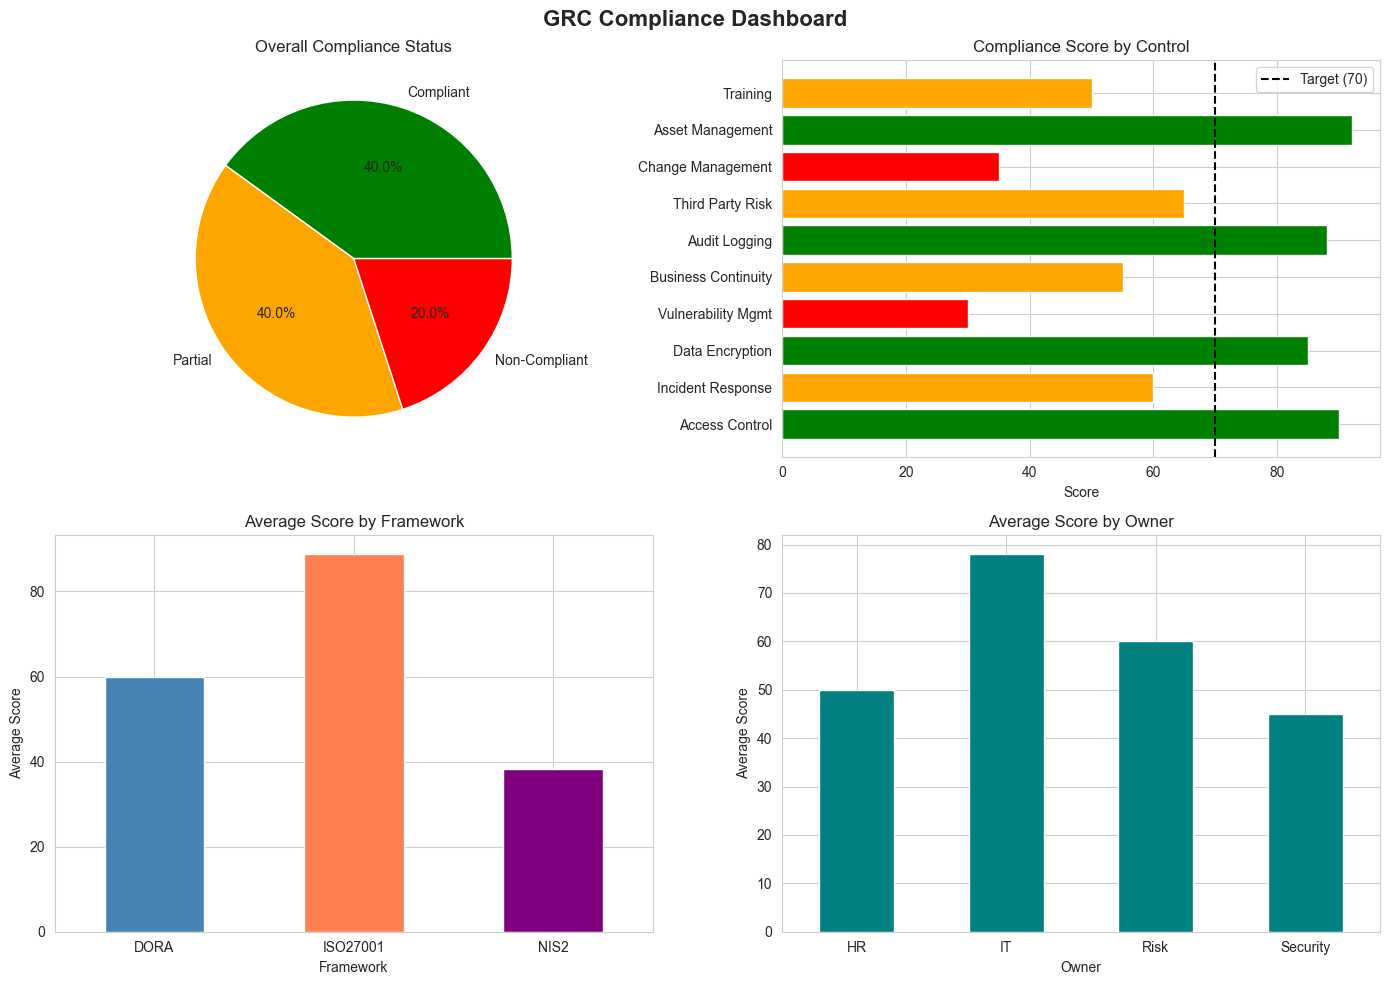

In [2]:
# Set up dashboard
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GRC Compliance Dashboard', fontsize=16, fontweight='bold')

# Chart 1 - Compliance Status Overview
status_counts = df['Status'].value_counts()
colors = ['green', 'orange', 'red']
axes[0,0].pie(status_counts, labels=status_counts.index, 
              autopct='%1.1f%%', colors=colors)
axes[0,0].set_title('Overall Compliance Status')

# Chart 2 - Score by Control
colors_bar = df['Status'].map({
    'Compliant': 'green',
    'Partial': 'orange',
    'Non-Compliant': 'red'
})
axes[0,1].barh(df['Control'], df['Score'], color=colors_bar)
axes[0,1].axvline(x=70, color='black', linestyle='--', label='Target (70)')
axes[0,1].set_title('Compliance Score by Control')
axes[0,1].set_xlabel('Score')
axes[0,1].legend()

# Chart 3 - Average Score by Framework
df.groupby('Framework')['Score'].mean().plot(kind='bar', ax=axes[1,0], 
                                              color=['steelblue', 'coral', 'purple'])
axes[1,0].set_title('Average Score by Framework')
axes[1,0].set_xlabel('Framework')
axes[1,0].set_ylabel('Average Score')
axes[1,0].tick_params(axis='x', rotation=0)

# Chart 4 - Score by Owner
df.groupby('Owner')['Score'].mean().plot(kind='bar', ax=axes[1,1], color='teal')
axes[1,1].set_title('Average Score by Owner')
axes[1,1].set_xlabel('Owner')
axes[1,1].set_ylabel('Average Score')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [3]:
print("=== EXECUTIVE COMPLIANCE SUMMARY ===\n")
print(f"Total Controls Assessed: {len(df)}")
print(f"Compliant: {len(df[df['Status']=='Compliant'])} ({len(df[df['Status']=='Compliant'])/len(df)*100:.0f}%)")
print(f"Partial: {len(df[df['Status']=='Partial'])} ({len(df[df['Status']=='Partial'])/len(df)*100:.0f}%)")
print(f"Non-Compliant: {len(df[df['Status']=='Non-Compliant'])} ({len(df[df['Status']=='Non-Compliant'])/len(df)*100:.0f}%)")
print(f"\nOverall Average Score: {df['Score'].mean():.1f}/100")
print(f"\nHighest Risk Controls:")
print(df[df['Status']=='Non-Compliant'][['Control', 'Framework', 'Score', 'Owner']].to_string(index=False))
print(f"\nFramework requiring most attention: {df.groupby('Framework')['Score'].mean().idxmin()}")
print(f"Owner requiring most support: {df.groupby('Owner')['Score'].mean().idxmin()}")


=== EXECUTIVE COMPLIANCE SUMMARY ===

Total Controls Assessed: 10
Compliant: 4 (40%)
Partial: 4 (40%)
Non-Compliant: 2 (20%)

Overall Average Score: 65.0/100

Highest Risk Controls:
           Control Framework  Score    Owner
Vulnerability Mgmt      NIS2     30 Security
 Change Management      NIS2     35       IT

Framework requiring most attention: NIS2
Owner requiring most support: Security
